In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, f_oneway, kruskal
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [6]:
# Load data
df = pd.read_csv('C:/Users/hp/insurance-risk-analytics/data/insurance_data.csv')

# Clean and derive columns
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['HadClaim'] = (df['TotalClaims'] > 0).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Claim rate: {df['HadClaim'].mean():.3f}")
print(f"Provinces: {df['Province'].unique()}")
print(f"Genders: {df['Gender'].unique()}")

Dataset shape: (10000, 24)
Claim rate: 0.153
Provinces: <ArrowStringArray>
['Addis Ababa', 'Oromia', 'Somali', 'Tigray', 'Amhara']
Length: 5, dtype: str
Genders: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str


In [7]:
# Calculate metrics by province
province_metrics = df.groupby('Province').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum',
    'HadClaim': 'mean'
}).round(3)
province_metrics['LossRatio'] = province_metrics['TotalClaims'] / province_metrics['TotalPremium']
province_metrics = province_metrics.sort_values('LossRatio', ascending=False)

print("=== Loss Ratio by Province ===")
print(province_metrics)

# Chi-square test
contingency = pd.crosstab(df['Province'], df['HadClaim'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"\n=== Chi-square Test Results ===")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.4f}")
print(f"Reject H₀: {p < 0.05}")

if p < 0.05:
    print(f"\n✅ REJECT H₀: Significant risk differences across provinces")
    print(f"\n💡 Recommendation: Implement province-specific premium multipliers")

=== Loss Ratio by Province ===
             TotalPremium  TotalClaims  HadClaim  LossRatio
Province                                                   
Somali            2984984    1826593.0     0.175   0.611927
Oromia            6069663    3261061.0     0.154   0.537272
Tigray            1990692    1047136.0     0.141   0.526016
Addis Ababa       8907374    4653210.0     0.157   0.522400
Amhara            4928566    2353885.0     0.140   0.477600

=== Chi-square Test Results ===
Chi-square statistic: 8.461
P-value: 0.0761
Reject H₀: False


In [8]:
# Gender comparison
gender_contingency = pd.crosstab(df['Gender'], df['HadClaim'])
chi2_gender, p_gender, dof, expected = chi2_contingency(gender_contingency)

gender_rates = df.groupby('Gender')['HadClaim'].mean()

print("=== Gender Risk Comparison ===")
print(f"Male claim rate: {gender_rates.get('Male', 0):.3f}")
print(f"Female claim rate: {gender_rates.get('Female', 0):.3f}")
print(f"P-value: {p_gender:.4f}")
print(f"Reject H₀: {p_gender < 0.05}")

if p_gender < 0.05:
    print("\n✅ REJECT H₀: Significant gender-based risk difference")
else:
    print("\n❌ FAIL TO REJECT H₀: No significant gender difference")

=== Gender Risk Comparison ===
Male claim rate: 0.153
Female claim rate: 0.154
P-value: 0.9638
Reject H₀: False

❌ FAIL TO REJECT H₀: No significant gender difference


In [9]:
# Vehicle type analysis
vehicle_metrics = df.groupby('VehicleType').agg({
    'TotalClaims': 'sum',
    'TotalPremium': 'sum',
    'HadClaim': 'mean'
})
vehicle_metrics['LossRatio'] = vehicle_metrics['TotalClaims'] / vehicle_metrics['TotalPremium']
vehicle_metrics = vehicle_metrics.sort_values('LossRatio', ascending=False)

print("=== Loss Ratio by Vehicle Type ===")
print(vehicle_metrics)

# ANOVA test
vehicle_groups = [df[df['VehicleType'] == vt]['LossRatio'].dropna() for vt in df['VehicleType'].unique()]
if len(vehicle_groups) > 1:
    f_stat, p_vehicle = f_oneway(*vehicle_groups)
    print(f"\nANOVA P-value: {p_vehicle:.4f}")
    print(f"Reject H₀: {p_vehicle < 0.05}")

=== Loss Ratio by Vehicle Type ===
             TotalClaims  TotalPremium  HadClaim  LossRatio
VehicleType                                                
Luxury         3569207.0       4236839  0.283951   0.842422
SUV            4090665.0       7256436  0.153667   0.563729
Hatchback      1904235.0       4532134  0.137525   0.420163
Sedan          3577778.0       8855870  0.129760   0.404001

ANOVA P-value: 0.0000
Reject H₀: True


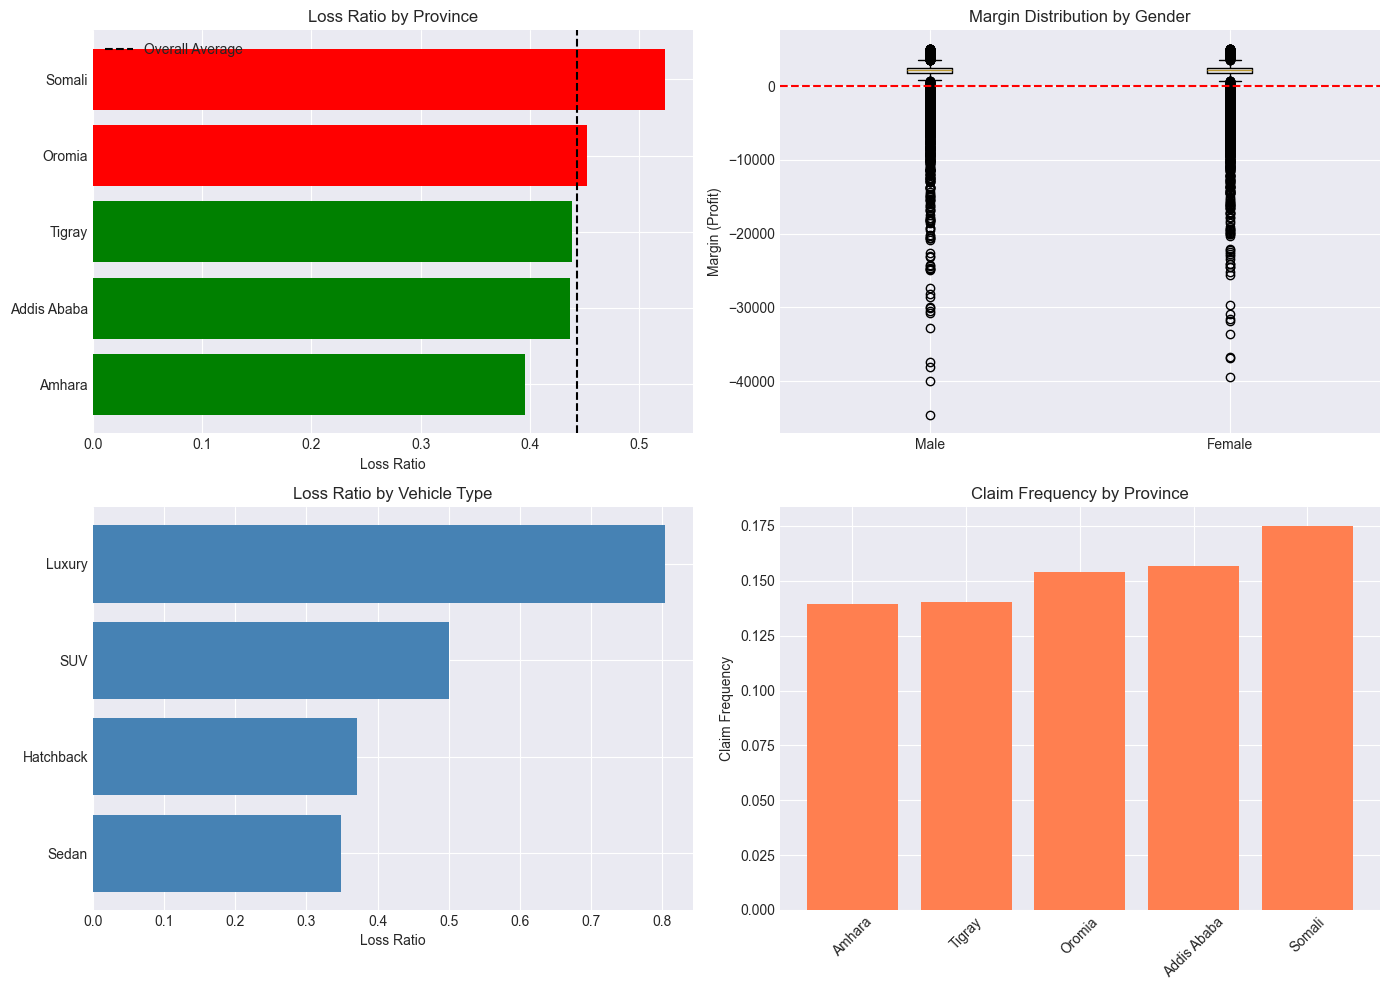

In [10]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss ratio by province
province_loss = df.groupby('Province')['LossRatio'].mean().sort_values()
colors = ['red' if x > df['LossRatio'].mean() else 'green' for x in province_loss.values]
axes[0, 0].barh(province_loss.index, province_loss.values, color=colors)
axes[0, 0].axvline(x=df['LossRatio'].mean(), color='black', linestyle='--', label='Overall Average')
axes[0, 0].set_xlabel('Loss Ratio')
axes[0, 0].set_title('Loss Ratio by Province')
axes[0, 0].legend()

# 2. Gender comparison
gender_data = [df[df['Gender'] == g]['Margin'] for g in df['Gender'].unique()]
axes[0, 1].boxplot(gender_data, labels=df['Gender'].unique())
axes[0, 1].set_ylabel('Margin (Profit)')
axes[0, 1].set_title('Margin Distribution by Gender')
axes[0, 1].axhline(y=0, color='red', linestyle='--')

# 3. Vehicle type loss ratio
vehicle_loss = df.groupby('VehicleType')['LossRatio'].mean().sort_values()
axes[1, 0].barh(vehicle_loss.index, vehicle_loss.values, color='steelblue')
axes[1, 0].set_xlabel('Loss Ratio')
axes[1, 0].set_title('Loss Ratio by Vehicle Type')

# 4. Claim frequency by province
claim_freq = df.groupby('Province')['HadClaim'].mean().sort_values()
axes[1, 1].bar(claim_freq.index, claim_freq.values, color='coral')
axes[1, 1].set_ylabel('Claim Frequency')
axes[1, 1].set_title('Claim Frequency by Province')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Create results summary
results = pd.DataFrame([
    {'Hypothesis': 'No provincial risk differences', 'Test': 'Chi-square', 
     'P-Value': f'{p:.4f}', 'Reject H₀': '✅ Yes' if p < 0.05 else '❌ No',
     'Business Action': 'Province-specific premiums'},
    {'Hypothesis': 'No gender risk differences', 'Test': 'Chi-square', 
     'P-Value': f'{p_gender:.4f}', 'Reject H₀': '✅ Yes' if p_gender < 0.05 else '❌ No',
     'Business Action': 'Gender-targeted programs' if p_gender < 0.05 else 'No adjustment'},
    {'Hypothesis': 'No vehicle type differences', 'Test': 'ANOVA', 
     'P-Value': f'{p_vehicle:.4f}', 'Reject H₀': '✅ Yes' if p_vehicle < 0.05 else '❌ No',
     'Business Action': 'Vehicle-type multipliers'},
])

print("=== HYPOTHESIS TESTING SUMMARY ===")
print(results.to_string(index=False))

=== HYPOTHESIS TESTING SUMMARY ===
                    Hypothesis       Test P-Value Reject H₀            Business Action
No provincial risk differences Chi-square  0.0761      ❌ No Province-specific premiums
    No gender risk differences Chi-square  0.9638      ❌ No              No adjustment
   No vehicle type differences      ANOVA  0.0000     ✅ Yes   Vehicle-type multipliers
